<a href="https://colab.research.google.com/github/medijay/msc-ai-phishing-detection/blob/main/notebooks/02_random_forest_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

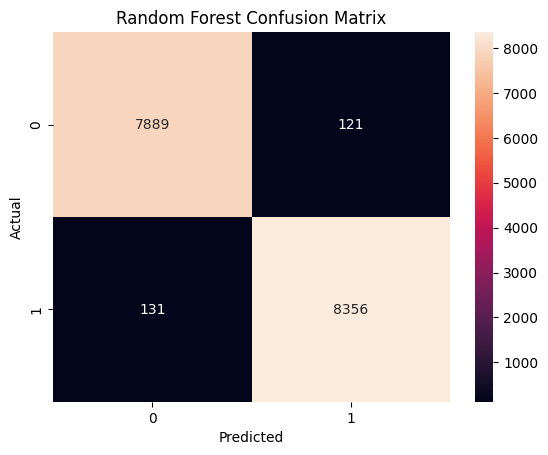

In [17]:
# This notebook implements a baseline phishing detection model
# using Random Forest on the preprocessed Allam dataset.

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Msc_phishing_Project/datasets/clean_allam_dataset.csv")

df.head()
df.info()
df['label'].value_counts()

X = df['clean_email']
y = df['label']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

X_train.isnull().sum()


df = df.dropna(subset=['clean_email'])

X = df['clean_email']
y = df['label']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_vec, y_train)

y_pred = rf_model.predict(X_test_vec)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

